In [ ]:
from nocode_robot_programming.state_decision.utils import kill_other_ipykernels
kill_other_ipykernels(force=True)
import trajectory_data
import matplotlib.pyplot as plt
from nocode_robot_programming.state_decision.dataloader import TrajectoryDataset
# from nocode_robot_programming.state_decision.dino_model import DINOFeaturePresence
# # from nocode_robot_programming.state_decision.dino_model_v2 import DINOFeaturePresence
# from nocode_robot_programming.state_decision.dino_model_v3 import DINOFeaturePresence
# from nocode_robot_programming.state_decision.SIFT_model import StateDeciderSIFT
from nocode_robot_programming.state_decision.AEGP_model import AEGP
# from nocode_robot_programming.state_decision.state_decider import StateDeciderBase
from nocode_robot_programming.state_decision.utils import Filename
from gesture_detector.utils import pretty_confusion_matrix
import torch
from torch.utils.data import DataLoader
import numpy as np
from copy import deepcopy
from trajectory_data.skill_visualizer import play_video
from nocode_robot_programming.state_decision.utils import add_tag
from nocode_robot_programming.state_decision.dataloader import ImageDatasetView, saved_img_processing
from nocode_robot_programming.jupyter_plot import jupyter_plot as ipt, show_gray_video_cuda

seed = 50
np.random.seed(seed); torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

from nocode_robot_programming.state_decision.dataset_D1 import d1_peg_pick, dupl
datafileloader = TrajectoryDataset(trajectory_data.package_path)
datasets = d1_peg_pick(datafileloader)

No other ipykernel_launcher processes found.
Found tasks:
Task        | # Files | Names (unique)                                                  | Trials | Offsets
------------+---------+-----------------------------------------------------------------+--------+--------
d1_peg_pick | 11      | d1_peg_pick, d1_peg_pick_branch_at_49, … (+9 more)              | -1-8   | 0-49   
d1_probe    | 9       | d1_probe, d1_probe_branch_at_51, d1_probe_trial_0, … (+6 more)  | -1-6   | 0-51   
d2_peg_pick | 7       | d2_peg_pick, d2_peg_pick_branch_at_76, … (+5 more)              | -1-4   | 0-76   
d2_probe    | 9       | d2_probe, d2_probe_branch_at_103, d2_probe_trial_0, … (+6 more) | -1-6   | 0-103  
d3_peg_pick | 5       | d3_peg_pick, d3_peg_pick_branch_at_189, … (+3 more)             | -1-2   | 0-189  
d3_probe    | 5       | d3_probe, d3_probe_branch_at_118, d3_probe_trial_0, … (+2 more) | -1-2   | 0-118  


# Video embedding bench

- I took the videoembedding from ILeSiA project, this model should be able to reconstruct images with details
#### 1. The autoencoder model very blurry reconstructions when training on a small dataset (~25 images), see here:

Epoch [49/50], Trainloss: 3.894, ValLoss: 0.003889: 100%|██████████| 50/50 [00:02<00:00, 18.14it/s] 



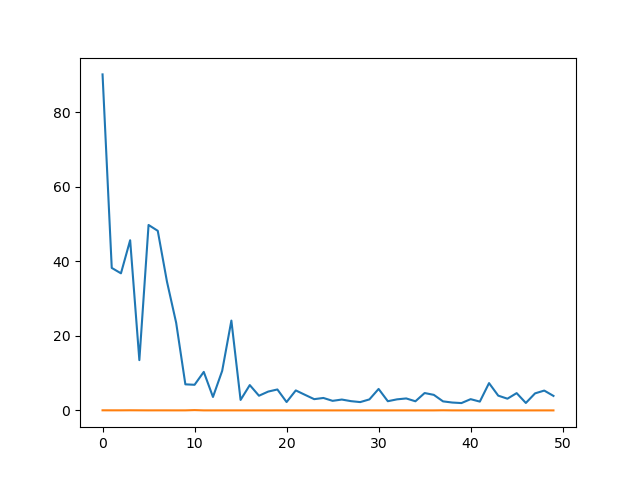

In [3]:
aegp = AEGP()
d_train, d_test, _ = datasets[0]

aegp.y_cls = d_train.y_cls
X = aegp._dataset_prepare(d_train.X)
aegp.videoembedder.training_loop(DataLoader(X, batch_size=1), num_epochs=50)

plt.plot(np.array([aegp.videoembedder.losses1, aegp.videoembedder.losses2]).T)
ipt.save(); ipt.show()
reconstructed_images = aegp.videoembedder.model.forward(d_train.X.unsqueeze(1)).squeeze()
display(show_gray_video_cuda(torch.concatenate([d_train.X, reconstructed_images], dim=2), fps=20, scale=5))

Problems: BatchNorm and tiny batches + small data

----

### 2. Repeat the input data 10x:

------------------------------------------------------
Samples: 21, dupl: 1


Epoch [49/50], Trainloss: 3.077, ValLoss: 0.00376: 100%|██████████| 50/50 [00:02<00:00, 19.83it/s]  



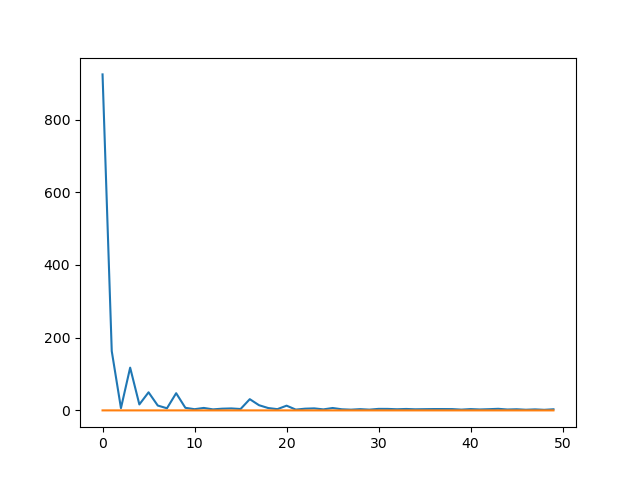

------------------------------------------------------
Samples: 21, dupl: 10


Epoch [49/50], Trainloss: 0.343, ValLoss: 0.000665: 100%|██████████| 50/50 [00:25<00:00,  1.99it/s]



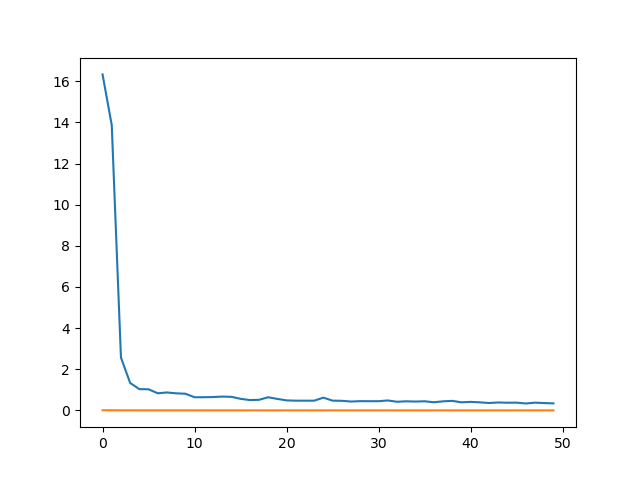

------------------------------------------------------
Samples: 21, dupl: 20


Epoch [49/50], Trainloss: 0.125, ValLoss: 0.00051: 100%|██████████| 50/50 [00:50<00:00,  1.01s/it] 



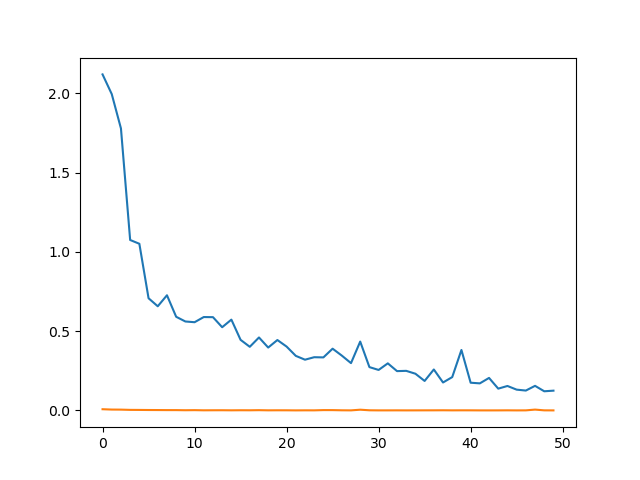

------------------------------------------------------
Samples: 55, dupl: 1


Epoch [49/50], Trainloss: 1.239, ValLoss: 0.002079: 100%|██████████| 50/50 [00:06<00:00,  7.58it/s]



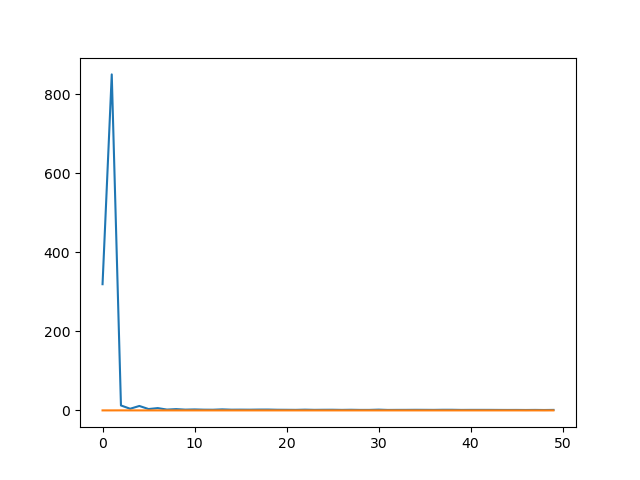

------------------------------------------------------
Samples: 55, dupl: 10


Epoch [12/50], Trainloss: 0.469, ValLoss: 0.001392:  26%|██▌       | 13/50 [00:17<00:49,  1.34s/it]


KeyboardInterrupt: 

: 

In [ ]:
for d_train, d_test, _ in datasets:
    for i in [1,10,20]:
        print("------------------------------------------------------")
        print(f"Samples: {d_train.X.size(0)}, dupl: {i}")
        aegp = AEGP()
        d_train_dupl = dupl(d_train, n=i)

        aegp.y_cls = d_train.y_cls
        X = aegp._dataset_prepare(d_train_dupl.X)
        aegp.videoembedder.training_loop(DataLoader(X, batch_size=1), num_epochs=50)

        plt.plot(np.array([aegp.videoembedder.losses1, aegp.videoembedder.losses2]).T)
        ipt.save(); ipt.show()
        reconstructed_images = aegp.videoembedder.model.forward(d_train.X.unsqueeze(1)).squeeze()
        display(show_gray_video_cuda(torch.concatenate([d_train.X, reconstructed_images], dim=2), fps=20, scale=5))

# Conclusion
### Configuration
- `batch_size=1`, `shuffle=False`, `drop_last=False`
- `3 x 3` runs - (trials split into train/test sets x duplication 1,10,20)
### Visual Evaluation
- 2 train trials + no duplication -> 1/10
- 2 train trials + 10 duplication -> 2/10
- 2 train trials + 20 duplication -> 3/10 (flickering)
- 5 train trials + no duplication -> 3/10 
- 5 train trials + 10 duplication -> 4/10 
- 5 train trials + 20 duplication -> 4.5/10 (heavy flickering)
- 8 train trials + no duplication -> 4
- 8 train trials + 10 duplication -> 5 (peg not reconstructed)
- 8 train trials + 20 duplication -> 6/10 (peg not reconstructed sometimes + flickering)

### Configuration
- `batch_size=1`, `shuffle=True`, `drop_last=True`
- `3 x 3` runs - (trials split into train/test sets x duplication 1,10,20)
### Visual Evaluation
- 2 train trials + no duplication -> 1.5/10
- 2 train trials + 10 duplication -> 5/10 (slight flickering)
- 2 train trials + 20 duplication -> 6/10 (slight flickering)
- 5 train trials + no duplication -> 2/10 
- 5 train trials + 10 duplication -> 3/10 (a lot of flickering, this should be much better but is not) 
- 5 train trials + 20 duplication -> 4/10 (a lot of flickering)
- 8 train trials + no duplication -> 3/10
- 8 train trials + 10 duplication -> 3.5/10 (peg not reconstructed)
- 8 train trials + 20 duplication -> 4.5/10 (peg sometimes not reconstructed)

### Configuration
- `batch_size=32`, `shuffle=True`, `drop_last=True`
- `3 x 3` runs - (trials split into train/test sets x duplication 1,10,20)
### Visual Evaluation
- 2 train trials + no duplication -> 0/10
- 2 train trials + 10 duplication -> 1/10 
- 2 train trials + 20 duplication -> 2/10 
- 5 train trials + no duplication -> 2/10 
- 5 train trials + 10 duplication -> 2/10
- 5 train trials + 20 duplication -> 4/10 (can see some peg, but flickering a lot) 
- 8 train trials + no duplication -> 1/10
- 8 train trials + 10 duplication -> 2.5/10 
- 8 train trials + 20 duplication -> 5/10 (peg kind of reconstructed, slight flickering)


In [ ]:
for d_train, d_test, _ in datasets:
    for i in [1,10,20]:
        print("------------------------------------------------------")
        print(f"Samples: {d_train.X.size(0)}, dupl: {i}")
        aegp = AEGP()
        d_train_dupl = dupl(d_train, n=i)

        aegp.y_cls = d_train.y_cls
        X = aegp._dataset_prepare(d_train_dupl.X)
        aegp.videoembedder.training_loop(DataLoader(X, batch_size=1, shuffle=True, drop_last=True), num_epochs=50)

        plt.plot(np.array([aegp.videoembedder.losses1, aegp.videoembedder.losses2]).T)
        ipt.save(); ipt.show()
        reconstructed_images = aegp.videoembedder.model.forward(d_train.X.unsqueeze(1)).squeeze()
        display(show_gray_video_cuda(torch.concatenate([d_train.X, reconstructed_images], dim=2), fps=20, scale=5))

In [ ]:
for d_train, d_test, _ in datasets:
    for i in [1,10,20]:
        print("------------------------------------------------------")
        print(f"Samples: {d_train.X.size(0)}, dupl: {i}")
        aegp = AEGP()
        d_train_dupl = dupl(d_train, n=i)

        aegp.y_cls = d_train.y_cls
        X = aegp._dataset_prepare(d_train_dupl.X)
        aegp.videoembedder.training_loop(DataLoader(X, batch_size=32, shuffle=True, drop_last=True), num_epochs=50)

        plt.plot(np.array([aegp.videoembedder.losses1, aegp.videoembedder.losses2]).T)
        ipt.save(); ipt.show()
        reconstructed_images = aegp.videoembedder.model.forward(d_train.X.unsqueeze(1)).squeeze()
        display(show_gray_video_cuda(torch.concatenate([d_train.X, reconstructed_images], dim=2), fps=20, scale=5))

# Winner?

In [ ]:
d_train, d_test, _ = datasets[0]
print(f"Samples: {d_train.X.size(0)}, dupl: 20")
aegp = AEGP()
d_train_dupl = dupl(d_train, n=20)

aegp.y_cls = d_train.y_cls
X = aegp._dataset_prepare(d_train_dupl.X)
aegp.videoembedder.training_loop(DataLoader(X, batch_size=1, shuffle=True, drop_last=True), num_epochs=50)

plt.plot(np.array([aegp.videoembedder.losses1, aegp.videoembedder.losses2]).T)
ipt.save(); ipt.show()
reconstructed_images = aegp.videoembedder.model.forward(d_train.X.unsqueeze(1)).squeeze()
display(show_gray_video_cuda(torch.concatenate([d_train.X, reconstructed_images], dim=2), fps=20, scale=5))

In [ ]:
d_train_dupl.X.shape

In [ ]:
import torch
import torchvision.transforms.functional as F
from torch.utils.data import Dataset

class TransformDataset(Dataset):
    def __init__(self, X, size=64, p_hflip=0.5):
        self.X = X                  # expect shape (N, 2, H, W) or list of two PILs per item
        self.size = size
        self.p_hflip = p_hflip

    def _paired_aug(self, x0, x1):
        # x*: tensor (1,H,W) or (H,W); values in [0,1]
        if x0.ndim == 2:  # make (1,H,W)
            x0 = x0.unsqueeze(0); x1 = x1.unsqueeze(0)

        H, W = x0.shape[-2:]
        # sample once
        do_hflip = torch.rand(()) < self.p_hflip
        angle = (torch.rand(()) * 10.0) - 5.0  # [-5°, +5°]
        do_crop = torch.rand(()) < 0.5
        if do_crop:
            scale = torch.empty(()).uniform_(0.90, 1.00)
            ratio = torch.empty(()).uniform_(0.98, 1.02)
            target = (H*W) * scale
            new_w = torch.clamp(torch.sqrt(target * ratio).round().long(), 1, W)
            new_h = torch.clamp(torch.sqrt(target / ratio).round().long(), 1, H)
            i = int(torch.randint(int((H-new_h).clamp(min=0)+1), ())) if new_h < H else 0
            j = int(torch.randint(int((W-new_w).clamp(min=0)+1), ())) if new_w < W else 0
            def crop_resize(z): return F.resized_crop(z, i, j, int(new_h), int(new_w), [self.size, self.size])
        else:
            def crop_resize(z): return F.resize(z, [self.size, self.size], antialias=True) if (H,W)!=(self.size,self.size) else z

        def apply(z):
            if do_hflip: z = F.hflip(z)
            z = crop_resize(z)
            if angle.abs() > 0:
                z = F.rotate(z, float(angle), interpolation=F.InterpolationMode.BILINEAR, fill=0.0)
            return z.clamp(0, 1)

        return apply(x0), apply(x1)

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        # assume tensors in [0,1]; if you store PIL images, call F.to_tensor first
        x0 = self.X[idx, 0]
        x1 = self.X[idx, 1]
        x0, x1 = self._paired_aug(x0, x1)
        return torch.cat([x0, x1], dim=0)   # (2, 64, 64)

In [ ]:
TransformDataset(X)[0]

In [ ]:
X.shape

In [ ]:
X = aegp._dataset_prepare(d_train_dupl.X)

d_train_X_tf_list = []
for i in range(10):
    d_train_X_tf_list.append(TransformDataset(X)[np.random.randint(420)])
d_train_X_tf = torch.concatenate(d_train_X_tf_list, dim=1)
display(show_gray_video_cuda(d_train_X_tf, fps=20, scale=5))

In [ ]:
d_train_X_tf.shape

In [ ]:
aegp = AEGP()

aegp.y_cls = d_train.y_cls
X = aegp._dataset_prepare(d_train_X_tf)
aegp.videoembedder.training_loop(DataLoader(TransformDataset(X), batch_size=1, shuffle=True, drop_last=True), num_epochs=100)

plt.plot(np.array([aegp.videoembedder.losses1, aegp.videoembedder.losses2]).T)
ipt.save(); ipt.show()
reconstructed_images = aegp.videoembedder.model.forward(d_train.X.unsqueeze(1)).squeeze()
display(show_gray_video_cuda(torch.concatenate([d_train.X, reconstructed_images], dim=2), fps=20, scale=5))

- Reconstruction is worse, when added augmentation